# Experiment 5: Decision Tree and Random Forest -- A Comparative Classification Study

Wisconsin Diagnostic Breast Cancer dataset, loaded directly via `sklearn.datasets.load_breast_cancer` (569 samples, 30 features, malignant/benign).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix)

sns.set_style("whitegrid")
rng = 42

## 1. Load Dataset and Encode Class Labels

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnosis")  # 0=malignant, 1=benign (already encoded)
target_names = data.target_names

print("Shape:", X.shape)
print("Missing values:", X.isnull().sum().sum())
y.map({0: "malignant", 1: "benign"}).value_counts()

Shape: (569, 30)
Missing values: 0


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

## 2. Exploratory Data Analysis

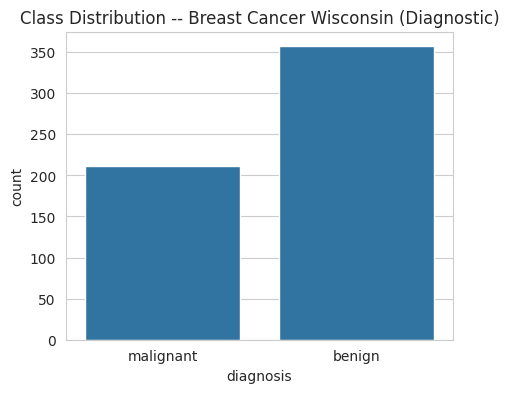

In [3]:
plt.figure(figsize=(5,4))
sns.countplot(x=y.map({0: "malignant", 1: "benign"}))
plt.title("Class Distribution -- Breast Cancer Wisconsin (Diagnostic)")
plt.show()

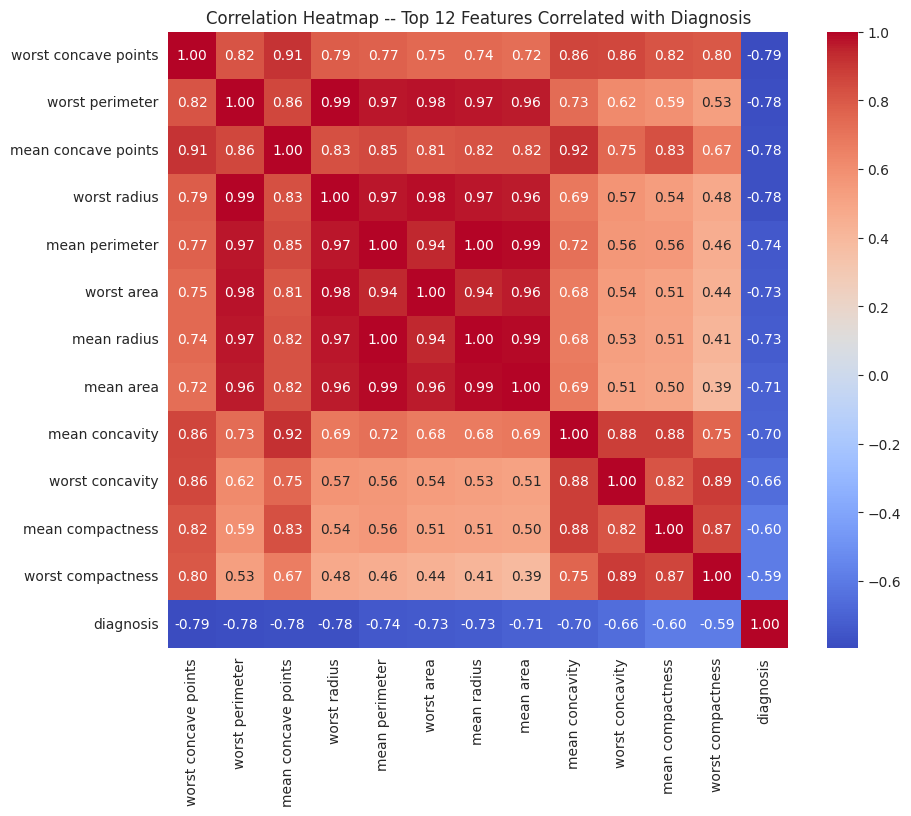

In [4]:
top_corr_feats = X.corrwith(y).abs().sort_values(ascending=False).head(12).index.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(pd.concat([X[top_corr_feats], y], axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap -- Top 12 Features Correlated with Diagnosis")
plt.show()

## 3. Train-Test Split (80:20, Stratified)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=rng)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (455, 30)  Test: (114, 30)


In [6]:
def evaluate(model, Xtr, ytr, Xte, yte):
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t0
    t0 = time.time()
    pred = model.predict(Xte)
    pred_time = time.time() - t0
    proba = model.predict_proba(Xte)[:, 1]
    metrics = dict(
        Accuracy=accuracy_score(yte, pred),
        Precision=precision_score(yte, pred),
        Recall=recall_score(yte, pred),
        F1=f1_score(yte, pred),
        ROC_AUC=roc_auc_score(yte, proba),
        TrainTime=train_time,
        PredictTime=pred_time,
    )
    return metrics, pred, proba

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=rng)

## 4. Train Baseline Decision Tree

In [7]:
dt_baseline = DecisionTreeClassifier(random_state=rng)
dt_baseline_metrics, dt_baseline_pred, dt_baseline_proba = evaluate(
    dt_baseline, X_train, y_train, X_test, y_test)
print("Baseline tree depth:", dt_baseline.get_depth())
dt_baseline_metrics

Baseline tree depth: 7


{'Accuracy': 0.9122807017543859,
 'Precision': 0.9558823529411765,
 'Recall': 0.9027777777777778,
 'F1': 0.9285714285714286,
 'ROC_AUC': 0.9156746031746031,
 'TrainTime': 0.00891423225402832,
 'PredictTime': 0.0009288787841796875}

## 5-6. Decision Tree Hyperparameter Search + 5-Fold CV (GridSearchCV)

In [8]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=rng), param_grid=dt_param_grid,
                        cv=skf, scoring="accuracy", n_jobs=-1)
dt_grid.fit(X_train, y_train)
print("Best params:", dt_grid.best_params_)
print("Best CV accuracy:", round(dt_grid.best_score_, 4))

Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV accuracy: 0.9385


In [9]:
best_dt = dt_grid.best_estimator_
best_dt_metrics, best_dt_pred, best_dt_proba = evaluate(best_dt, X_train, y_train, X_test, y_test)
print("Best tree depth:", best_dt.get_depth())
best_dt_metrics

Best tree depth: 5


{'Accuracy': 0.9035087719298246,
 'Precision': 0.9420289855072463,
 'Recall': 0.9027777777777778,
 'F1': 0.9219858156028369,
 'ROC_AUC': 0.9358465608465609,
 'TrainTime': 0.006227731704711914,
 'PredictTime': 0.0007381439208984375}

## 7-9. Random Forest: Baseline, Hyperparameter Search + 5-Fold CV

In [10]:
rf_baseline = RandomForestClassifier(random_state=rng)
rf_baseline_metrics, rf_baseline_pred, rf_baseline_proba = evaluate(
    rf_baseline, X_train, y_train, X_test, y_test)
rf_baseline_metrics

{'Accuracy': 0.956140350877193,
 'Precision': 0.958904109589041,
 'Recall': 0.9722222222222222,
 'F1': 0.9655172413793104,
 'ROC_AUC': 0.9937169312169312,
 'TrainTime': 0.1653895378112793,
 'PredictTime': 0.0074236392974853516}

In [11]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=rng), param_grid=rf_param_grid,
                        cv=skf, scoring="accuracy", n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("Best params:", rf_grid.best_params_)
print("Best CV accuracy:", round(rf_grid.best_score_, 4))

Best params: {'bootstrap': True, 'max_depth': 10, 'max_features': 'log2', 'n_estimators': 100}
Best CV accuracy: 0.9648


In [12]:
best_rf = rf_grid.best_estimator_
best_rf_metrics, best_rf_pred, best_rf_proba = evaluate(best_rf, X_train, y_train, X_test, y_test)
best_rf_metrics

{'Accuracy': 0.956140350877193,
 'Precision': 0.958904109589041,
 'Recall': 0.9722222222222222,
 'F1': 0.9655172413793104,
 'ROC_AUC': 0.9923941798941799,
 'TrainTime': 0.15591740608215332,
 'PredictTime': 0.007933855056762695}

## 10. 5-Fold Cross-Validation: Tuned Decision Tree vs. Tuned Random Forest

In [13]:
dt_cv_scores = cross_val_score(DecisionTreeClassifier(**dt_grid.best_params_, random_state=rng),
                                X, y, cv=skf, scoring="accuracy")
rf_cv_scores = cross_val_score(RandomForestClassifier(**rf_grid.best_params_, random_state=rng),
                                X, y, cv=skf, scoring="accuracy")

print("DT folds:", dt_cv_scores.round(4), " avg:", round(dt_cv_scores.mean(),4))
print("RF folds:", rf_cv_scores.round(4), " avg:", round(rf_cv_scores.mean(),4))

DT folds: [0.9211 0.8947 0.9386 0.9298 0.9381]  avg: 0.9245
RF folds: [0.9649 0.9561 0.9561 0.9561 0.9646]  avg: 0.9596


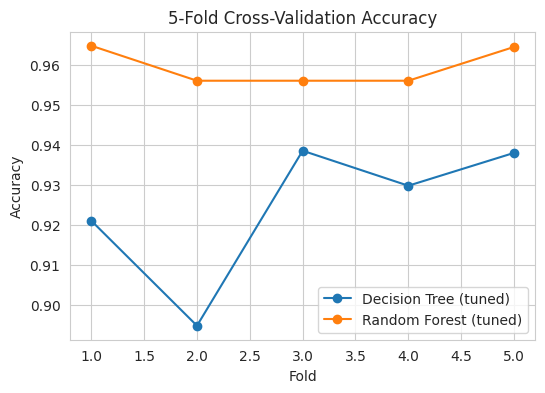

In [14]:
plt.figure(figsize=(6,4))
folds = list(range(1,6))
plt.plot(folds, dt_cv_scores, "o-", label="Decision Tree (tuned)")
plt.plot(folds, rf_cv_scores, "o-", label="Random Forest (tuned)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.legend()
plt.show()

## 11. Overfitting Analysis: max_depth (Decision Tree) and n_estimators (Random Forest)

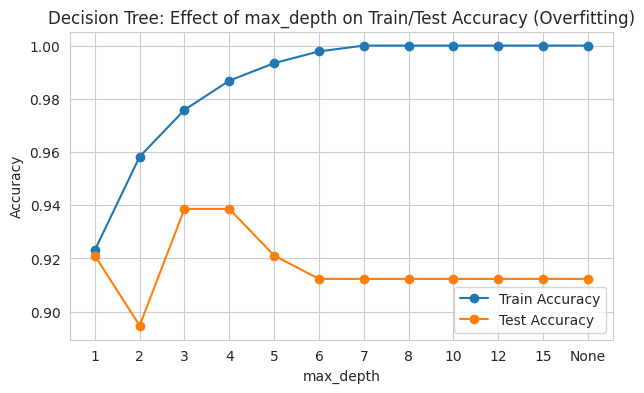

In [15]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, None]
depth_curve = {}
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=rng)
    dt.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    depth_curve[str(d)] = (train_acc, test_acc)

depth_labels = [str(d) for d in depths]
plt.figure(figsize=(7,4))
plt.plot(depth_labels, [depth_curve[d][0] for d in depth_labels], "o-", label="Train Accuracy")
plt.plot(depth_labels, [depth_curve[d][1] for d in depth_labels], "o-", label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Effect of max_depth on Train/Test Accuracy (Overfitting)")
plt.legend()
plt.show()

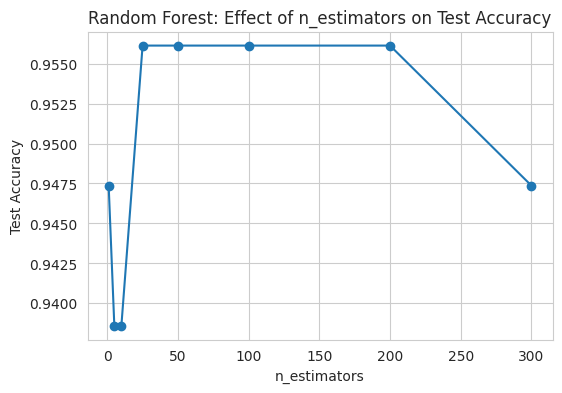

In [16]:
n_est_values = [1, 5, 10, 25, 50, 100, 200, 300]
n_est_curve = {}
for n in n_est_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=rng)
    rf.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    n_est_curve[n] = test_acc

plt.figure(figsize=(6,4))
plt.plot(list(n_est_curve.keys()), list(n_est_curve.values()), "o-")
plt.xlabel("n_estimators")
plt.ylabel("Test Accuracy")
plt.title("Random Forest: Effect of n_estimators on Test Accuracy")
plt.show()

## Confusion Matrices and ROC Curves

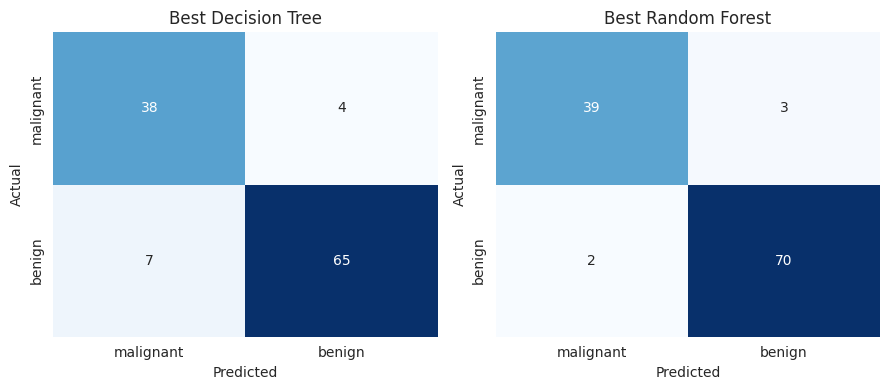

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9,4))
for ax, (name, pred) in zip(axes, [("Best Decision Tree", best_dt_pred), ("Best Random Forest", best_rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["malignant","benign"], yticklabels=["malignant","benign"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

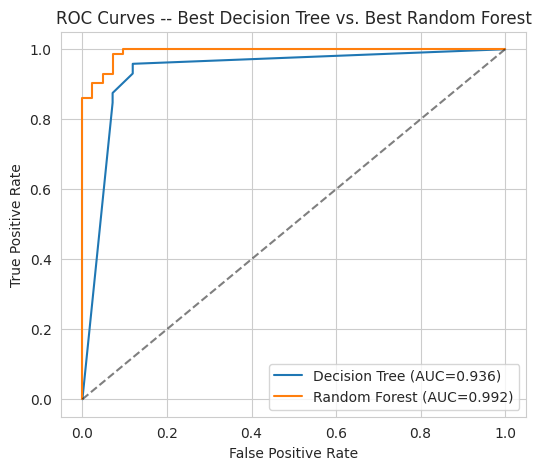

In [18]:
plt.figure(figsize=(6,5))
fpr, tpr, _ = roc_curve(y_test, best_dt_proba)
plt.plot(fpr, tpr, label=f"Decision Tree (AUC={roc_auc_score(y_test, best_dt_proba):.3f})")
fpr, tpr, _ = roc_curve(y_test, best_rf_proba)
plt.plot(fpr, tpr, label=f"Random Forest (AUC={roc_auc_score(y_test, best_rf_proba):.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves -- Best Decision Tree vs. Best Random Forest")
plt.legend()
plt.show()

## 12. Feature Importance (Random Forest) and Tree Visualization

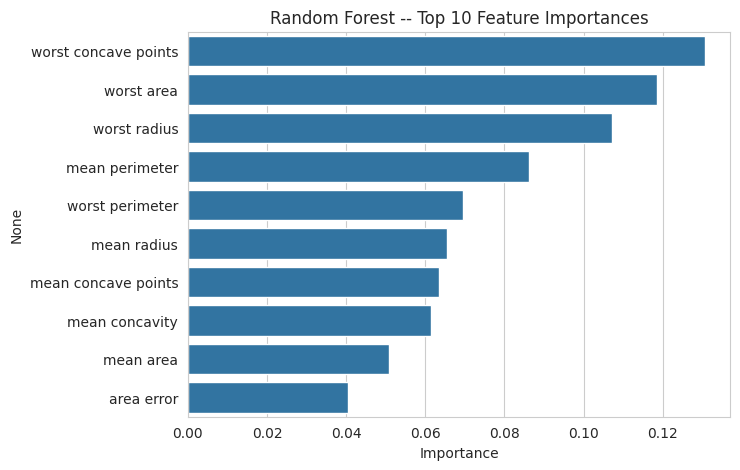

In [19]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest -- Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

## 13. Decision Tree Visualization

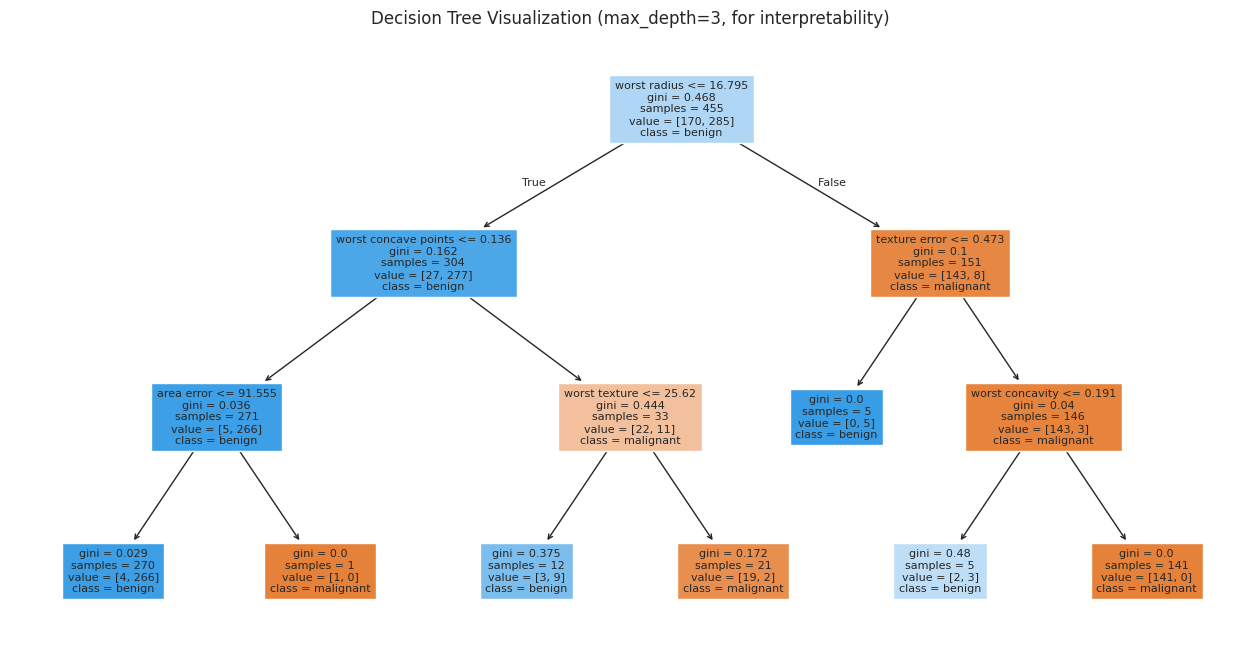

In [20]:
plt.figure(figsize=(16,8))
small_tree = DecisionTreeClassifier(max_depth=3, random_state=rng)
small_tree.fit(X_train, y_train)
plot_tree(small_tree, feature_names=X.columns, class_names=["malignant","benign"],
          filled=True, fontsize=8)
plt.title("Decision Tree Visualization (max_depth=3, for interpretability)")
plt.show()

## 14. Classifier Comparison

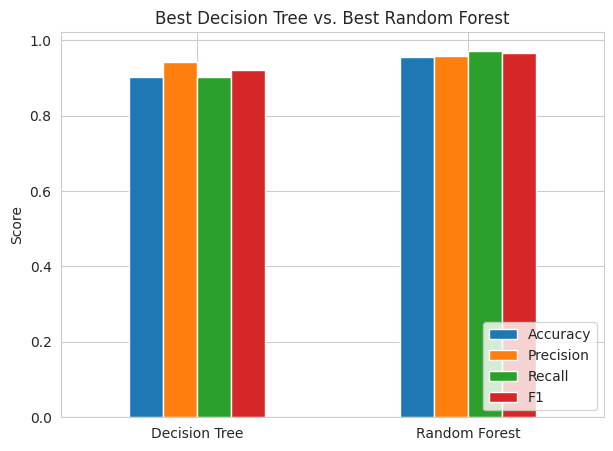

,Accuracy,Precision,Recall,F1
Decision Tree,0.903509,0.942029,0.902778,0.921986
Random Forest,0.956140,0.958904,0.972222,0.965517


In [21]:
compare_df = pd.DataFrame({
    "Decision Tree": best_dt_metrics,
    "Random Forest": best_rf_metrics,
}).T[["Accuracy", "Precision", "Recall", "F1"]]

compare_df.plot(kind="bar", figsize=(7,5))
plt.title("Best Decision Tree vs. Best Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()
compare_df

## Summary

See the accompanying report (`Experiment5.pdf`) for the full observation-question answers, discussion, and conclusion grounded in these results.